In [1]:
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
df=pd.read_csv("loan_data.csv")

In [7]:

X = df.drop("loan_status", axis=1)
y = df["loan_status"]


 
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

 
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)


 
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight = {i: class_weights[i] for i in range(len(class_weights))}
 
model = keras.Sequential([
    layers.Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])



model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-6),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC()]
)



callbacks = [
    EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss",factor=0.5, patience=7,min_lr=1e-7)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)


Epoch 1/50


c:\Users\user\.conda\envs\mlenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


985/985 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5028 - auc_2: 0.6226 - loss: 0.6802 - val_accuracy: 0.5351 - val_auc_2: 0.7102 - val_loss: 0.6888 - learning_rate: 1.0000e-06
Epoch 2/50
985/985 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5600 - auc_2: 0.6964 - loss: 0.6688 - val_accuracy: 0.6052 - val_auc_2: 0.7713 - val_loss: 0.6791 - learning_rate: 1.0000e-06
Epoch 3/50
985/985 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6143 - auc_2: 0.7503 - loss: 0.6559 - val_accuracy: 0.6610 - val_auc_2: 0.8131 - val_loss: 0.6673 - learning_rate: 1.0000e-06
Epoch 4/50
985/985 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6601 - auc_2: 0.7891 - loss: 0.6422 - val_accuracy: 0.7093 - val_auc_2: 0.8416 - val_loss: 0.6525 - learning_rate: 1.0000e-06
Epoch 5/50
985/985 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7032 - auc_2: 0.8189 - loss: 0.6263 - val_accuracy: 0.7393 - val_auc_2: 0.8609 - val_loss: 0.6355 - learning_rate: 1.0000e-06
Epoch 6/50
985/985 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step

Accuracy: 0.8602962962962963

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90      5250
           1       0.63      0.91      0.74      1500

    accuracy                           0.86      6750
   macro avg       0.80      0.88      0.82      6750
weighted avg       0.89      0.86      0.87      6750



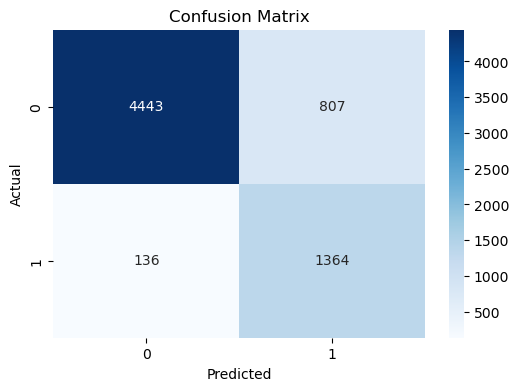

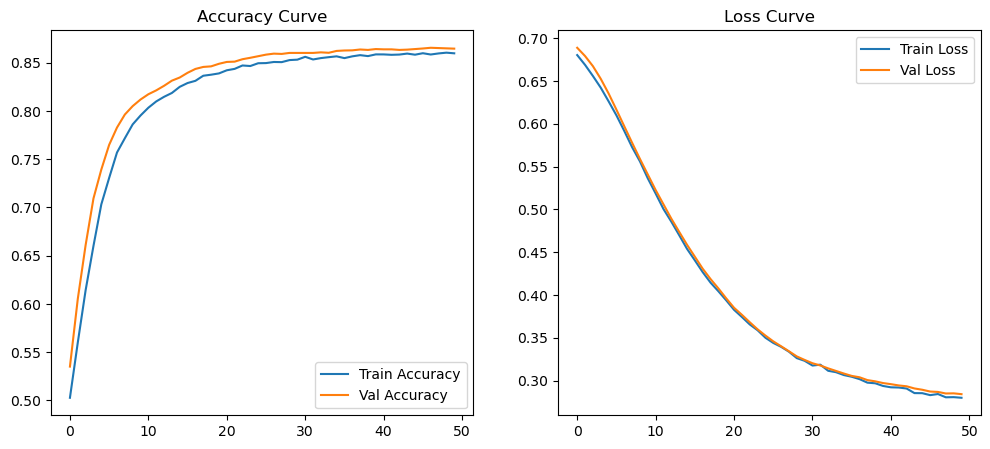

In [8]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.legend()

plt.show()